In [13]:
import numpy as np
import matplotlib.pyplot as plt
import millefeuille as mf

state = mf.State.load(
    "databases/Gorgon_MF_DB_Gorgon_MF_20MA_iceburner2.db"
)

surrogate = mf.MultiOutputRandomForestSurrogate(
    n_outputs=len(state.Y_names),
    verbose=True,
)

surrogate.fit(state)

In [14]:
# DT ice geometry helpers
#
# The surrogate was trained using Pi_parameter rather than DT ice thickness
# as a direct input. Therefore, a desired DT ice thickness must first be
# converted into the Pi_parameter that produces that thickness.

RHO_BE = 1.85e3   # kg m^-3
RHO_DT = 0.92e3   # kg m^-3


def dt_ice_thickness_from_design(
    R_outer,
    Pi_parameter,
    Be_thickness,
    rho_be=RHO_BE,
    rho_dt=RHO_DT,
):
    """Return DT ice thickness in metres."""
    R_be_inner = R_outer - Be_thickness

    if np.any(R_be_inner <= 0):
        raise ValueError("Be_thickness must be smaller than R_outer.")

    # Same mass convention used in the simulator.
    m_shell = Pi_parameter / R_outer**2
    m_be = np.pi * (R_outer**2 - R_be_inner**2) * rho_be
    m_dt = m_shell - m_be

    radicand = R_be_inner**2 - m_dt / (np.pi * rho_dt)

    if np.any(m_dt <= 0):
        raise ValueError("The selected design gives non-positive DT ice mass.")
    if np.any(radicand <= 0):
        raise ValueError("The selected design gives an invalid DT inner radius.")

    R_dt_inner = np.sqrt(radicand)
    return R_be_inner - R_dt_inner


def pi_from_dt_ice_thickness(
    dt_ice_thickness,
    R_outer,
    Be_thickness,
    rho_be=RHO_BE,
    rho_dt=RHO_DT,
):
    """Return the Pi_parameter required for a target DT ice thickness."""
    R_be_inner = R_outer - Be_thickness
    R_dt_inner = R_be_inner - dt_ice_thickness

    if np.any(R_be_inner <= 0):
        raise ValueError("Be_thickness must be smaller than R_outer.")
    if np.any(R_dt_inner <= 0):
        raise ValueError("DT ice thickness is too large for this geometry.")
    if np.any(dt_ice_thickness <= 0):
        raise ValueError("DT ice thickness must be positive.")

    m_be = np.pi * (R_outer**2 - R_be_inner**2) * rho_be
    m_dt = np.pi * (R_be_inner**2 - R_dt_inner**2) * rho_dt
    m_shell = m_be + m_dt

    return m_shell * R_outer**2


In [15]:
# Fixed design about which the one-dimensional scan is performed.
# Only the DT ice thickness changes. This is implemented by changing
# Pi_parameter consistently with the target thickness.

X_default = np.array([
    0.84e3,     # laser_energy
    2.79e-3,    # R_outer
    1.20e-7,    # Pi_parameter
    3.25e-4,    # Be_thickness
    2.25,       # rho_gas
], dtype=float)

print("Surrogate inputs:", list(state.X_names))

idx_R = list(state.X_names).index("R_outer")
idx_Pi = list(state.X_names).index("Pi_parameter")
idx_Be = list(state.X_names).index("Be_thickness")

R_fixed = X_default[idx_R]
Be_fixed = X_default[idx_Be]

# Keep the scan within the Pi_parameter range used for the 20 MA study.
# With the fixed geometry above, this is approximately 400–454 micrometres.
Pi_min = 1.18e-7
Pi_max = 1.23e-7

t_min = dt_ice_thickness_from_design(R_fixed, Pi_min, Be_fixed)
t_max = dt_ice_thickness_from_design(R_fixed, Pi_max, Be_fixed)

DT_ice_scan = np.linspace(min(t_min, t_max), max(t_min, t_max), 150)
DT_ice_scan_um = DT_ice_scan * 1e6

X_pred = np.tile(X_default, (len(DT_ice_scan), 1))

# Convert each requested DT thickness to a physically consistent Pi value.
X_pred[:, idx_Pi] = pi_from_dt_ice_thickness(
    DT_ice_scan,
    R_outer=R_fixed,
    Be_thickness=Be_fixed,
)

Y_pred = surrogate.predict(state, X_pred)
Y_mean = np.asarray(Y_pred["mean"], dtype=float)
Y_std = np.asarray(Y_pred["std"], dtype=float)

print(
    f"DT ice thickness scan: "
    f"{DT_ice_scan_um.min():.1f}–{DT_ice_scan_um.max():.1f} micrometres"
)
print(
    f"Corresponding Pi range: "
    f"{X_pred[:, idx_Pi].min():.3e}–{X_pred[:, idx_Pi].max():.3e}"
)


Surrogate inputs: ['laser_energy', 'R_outer', 'Pi_parameter', 'Be_thickness', 'rho_gas']
DT ice thickness scan: 399.7–454.2 micrometres
Corresponding Pi range: 1.180e-07–1.230e-07


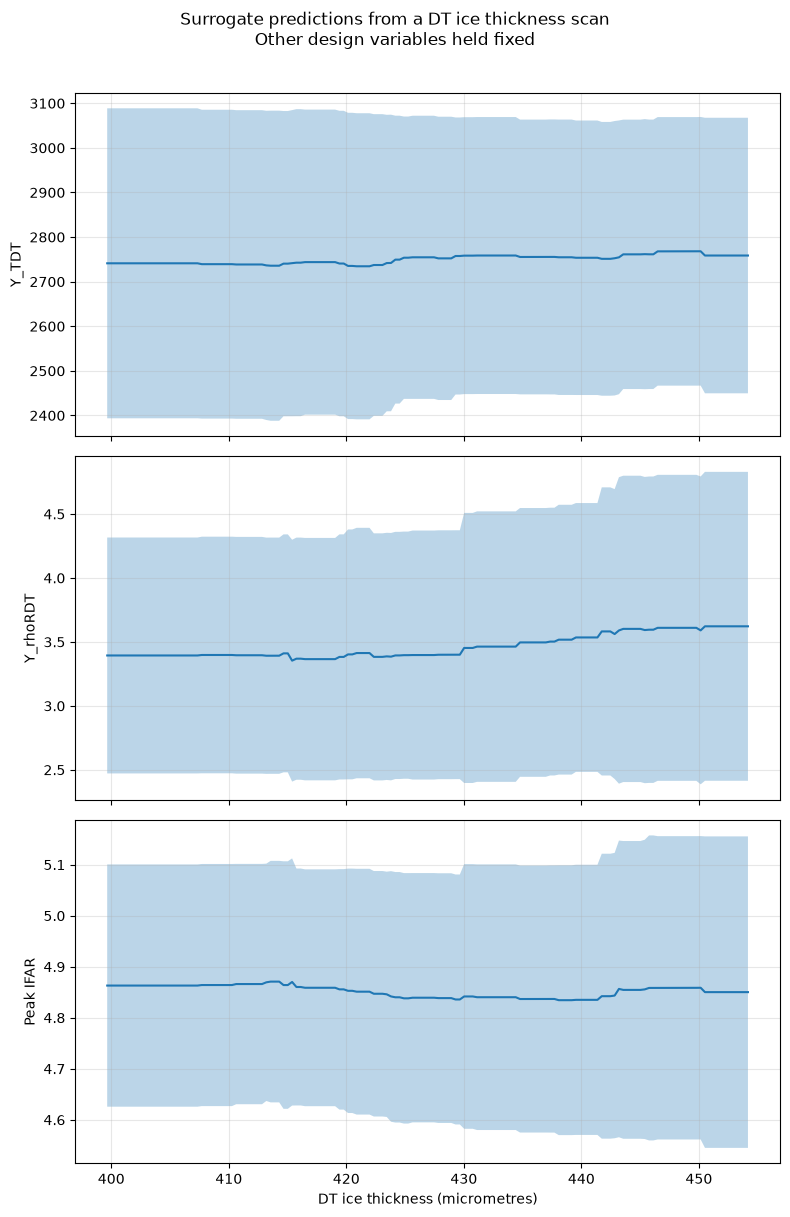

In [16]:
fig, axes = plt.subplots(
    len(state.Y_names),
    1,
    figsize=(8, 4 * len(state.Y_names)),
    sharex=True,
)

axes = np.atleast_1d(axes)

for i, name in enumerate(state.Y_names):
    mean = Y_mean[:, i]
    std = Y_std[:, i]

    # Convert the negative IFAR objective back to physical peak IFAR.
    if name == "Y_minus_peak_IFAR":
        plot_mean = -mean
        lower = -(mean + std)
        upper = -(mean - std)
        ylabel = "Peak IFAR"
    else:
        plot_mean = mean
        lower = mean - std
        upper = mean + std
        ylabel = name

    axes[i].plot(DT_ice_scan_um, plot_mean)
    axes[i].fill_between(
        DT_ice_scan_um,
        lower,
        upper,
        alpha=0.3,
    )

    axes[i].set_ylabel(ylabel)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("DT ice thickness (micrometres)")

fig.suptitle(
    "Surrogate predictions from a DT ice thickness scan\n"
    "Other design variables held fixed",
    y=1.01,
)

plt.tight_layout()
plt.show()
